# Glaze triangles: raw data to analysis tables

Creates **`metadata_df`** (one row per stored session, including practice) and **`trials_df`** (one row per stored trial slot). **`analysis_trials`** selects non-practice trials with recorded responses. No performance or reaction-time exclusions are applied. Participant IDs are the full filename suffix; IDs with similar prefixes are not merged.

Run all cells with Python, NumPy, pandas, SciPy, matplotlib, and Jupyter installed (already listed in the repository requirements). Paths work from this notebook's folder or the repository root. The source MAT files are never modified.

### Alignment and source evidence

- [Raw README](../data/Glaze_Triangles/data_2AFC/raw_data/README.txt): `X` stores star coordinates; `pred` stores the response after that star, coded 1 = left and 2 = right.
- [Task GUI](../data/Glaze_Triangles/task_2AFC/proto_hazard_taskGUI.m), lines 239–293: displays `X(data.n,:)`, waits for a response, stores `rt(data.n) = 1000*toc` and `pred(data.n)`. **Pair `X[t]` with `pred[t]` directly; do not shift either.** RT is milliseconds from the GUI's timer after stimulus blinking, not necessarily the first visual onset.
- [Decision extraction](../data/Glaze_Triangles/analysis_2AFC/extract_decision_data.m), lines 19–21: uses `pred(2:end)` and `X(2:end,:)` together, comparing responses with the *previous* true source for a switch analysis. That previous-source comparison is not a reason to shift the stimulus–choice pairing.
- [Generator](../data/Glaze_Triangles/task_2AFC/generate_task_data.m): stores both source-specific hazards, draws a source switch before the current stimulus, and pre-generates the entire session. Feedback `signaled[t]` is revealed **after** response t. First stimuli are specially constrained and coordinates are clipped at display boundaries.

### Corrections and inclusion decisions

The README documents reciprocal hazards. The supplied analysis directory contains references to an unavailable `analyze_subject` function; inspection did not locate an executable correction there. We therefore implement the documented reciprocal correction explicitly: if an array contains values above 1, require *all* its values to be at least 1 and invert the whole array. Apply independently to `H` and `Hset`, retain originals, and validate the resulting probabilities and block schedule. Mixed probability/reciprocal encodings raise an error instead of being guessed.

`cp` and `r` are retained as raw fields. The README describes an apparent-stimulus change, but the supplied generator uses latent-source changes. We independently compute source switches from `muinds` and report agreement. The first source switch is undefined, rather than counting the generator's artificial `cp[0] = 1` as a transition.

A zero `pred` denotes no recorded response, not a left choice. Such slots remain in `trials_df` with missing `choice`/`correct`; presentation cannot be established from pre-generated `X` alone. Practice is retained and flagged. Actual per-trial feedback takes precedence over planned session parameters, which are preserved separately. Missing rewards, dates, or planned parameters remain missing; no defaults are invented.

In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import loadmat
from IPython.display import display

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "data/Glaze_Triangles/data_2AFC/raw_data/README.txt").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("Run from the repository root or one of its subdirectories.")
RAW = ROOT / "data/Glaze_Triangles/data_2AFC/raw_data"
files = sorted(RAW.glob("data_*.mat"))
assert files, f"No participant MAT files in {RAW}"
sex_lookup = dict(loadmat(RAW / "subjdata.mat", simplify_cells=True)["subjsex"])
print(f"Found {len(files)} participant files.")


Found 57 participant files.


In [2]:
def scalar_or_missing(value):
    a = np.asarray(value)
    return a.item() if a.size == 1 else np.nan


def correct_hazards(value, label):
    raw = np.asarray(value, dtype=float)
    assert np.isfinite(raw).all() and (raw >= 0).all(), label
    reciprocal = bool((raw > 1).any())
    if reciprocal:
        assert (raw >= 1).all(), f"Mixed hazard encodings: {label}"
    corrected = 1 / raw if reciprocal else raw.copy()
    assert ((corrected >= 0) & (corrected <= 1)).all(), label
    return raw, corrected, reciprocal


def feedback_type(values):
    return { (0,): "unsignaled", (1,): "signaled", (0, 1): "mixed" }[tuple(np.unique(values))]


metadata_rows, trial_frames = [], []
files_without_sessions = []
for path in files:
    subject = path.stem.removeprefix("data_")
    contents = loadmat(path, simplify_cells=True)
    params = contents.get("session_params", [])
    params = [params] if isinstance(params, dict) else list(params)
    names = sorted((k for k in contents if re.fullmatch(r"data\d+(_practice)?", k)),
                   key=lambda k: (int(re.search(r"\d+", k)[0]), "practice" not in k))
    if not names:
        files_without_sessions.append(path.name)
    for name in names:
        d = contents[name]
        session = int(re.search(r"\d+", name)[0])
        practice = name.endswith("_practice")
        uid = f"{subject}:{name}"
        planned = params[session - 1] if session <= len(params) else {}
        n = int(d["N"])
        x = np.asarray(d["X"], float)
        means = np.asarray(d["muall"], float)
        pred = np.asarray(d["pred"], int).reshape(-1)
        source = np.asarray(d["muinds"], int).reshape(-1)
        feedback = np.asarray(d["signaled"], int).reshape(-1)
        rt = np.asarray(d["rt"], float).reshape(-1)
        cp = np.asarray(d["cp"], int).reshape(-1)
        run_raw = np.asarray(d["r"], int).reshape(-1)
        assert x.shape == (n, 2) and means.shape == (2, 2), uid
        assert all(len(a) == n for a in [pred, source, feedback, rt, cp, run_raw]), uid
        assert np.isin(pred, [0, 1, 2]).all() and np.isin(source, [1, 2]).all(), uid
        assert np.isin(feedback, [0, 1]).all() and np.isin(cp, [0, 1]).all(), uid
        assert np.isfinite(x).all() and np.isfinite(means).all(), uid
        assert means[0, 0] < means[1, 0], uid
        h_raw, h, h_fixed = correct_hazards(d["H"], uid)
        assert h.shape == (n, 2), uid
        boundary = np.r_[True, np.any(~np.isclose(h[1:], h[:-1]), axis=1)]
        block = boundary.cumsum()
        block_trial = np.arange(n) - np.maximum.accumulate(np.where(boundary, np.arange(n), 0)) + 1
        hs_raw = hs = None
        hs_fixed = False
        schedule_ok = pd.NA
        if "Hset" in d:
            hs_raw, hs, hs_fixed = correct_hazards(d["Hset"], uid + ":Hset")
            assert hs.ndim == 2 and hs.shape[0] == 2 and n % hs.shape[1] == 0, uid
            schedule_ok = bool(np.allclose(h, np.repeat(hs.T, n // hs.shape[1], axis=0)))
            assert schedule_ok, f"H does not match Hset: {uid}"
        switch = pd.array(np.r_[False, source[1:] != source[:-1]], dtype="boolean")
        switch[0] = pd.NA
        source_boundary = np.r_[True, source[1:] != source[:-1]]
        source_run = np.arange(n) - np.maximum.accumulate(np.where(source_boundary, np.arange(n), 0)) + 1
        responded = pred != 0
        choice = pd.array(pred, dtype="Int64")
        choice[~responded] = pd.NA
        correct = pd.array(pred == source, dtype="boolean")
        correct[~responded] = pd.NA
        sigma = float(d["sigma"])
        mode = feedback_type(feedback)
        midpoint = means[:, 0].mean()
        reward = scalar_or_missing(d.get("reward", []))
        penalty = scalar_or_missing(d.get("penalty", []))
        row = dict(session_uid=uid, subject_id=subject, session_number=session,
                   is_practice=practice, source_file=path.relative_to(ROOT).as_posix(),
                   matlab_variable=name, sex_recorded=sex_lookup.get(subject, pd.NA),
                   n_stored_trials=n, n_responses=int(responded.sum()), n_counter_raw=int(d["n"]),
                   feedback_condition=mode, planned_signaled_code=scalar_or_missing(planned.get("signaled", [])),
                   sigma=sigma, stimulus_variance=sigma**2, n_hazard_blocks=int(block.max()),
                   hazard_block_lengths=tuple(np.bincount(block)[1:]),
                   Hset_raw=None if hs_raw is None else hs_raw.tolist(),
                   Hset_corrected=None if hs is None else hs.tolist(),
                   tau_raw=np.asarray(d.get("tau", [])).tolist(),
                   hazard_reciprocal_corrected=h_fixed, Hset_reciprocal_corrected=hs_fixed,
                   Hset_schedule_matches=schedule_ok, reward_raw=reward, penalty_raw=penalty,
                   sessionstart_matlab_datenum=scalar_or_missing(d.get("sessionstart", [])),
                   session_ind_file_raw=scalar_or_missing(contents.get("session_ind", [])),
                   planned_parameters_raw=planned,
                   cp_matches_source_switch=bool(np.array_equal(cp[1:], source[1:] != source[:-1])),
                   r_matches_source_run=bool(np.array_equal(run_raw, source_run)))
        for i, side in enumerate(["left", "right"]):
            for j, axis in enumerate(["x", "y"]):
                row[f"source_{side}_{axis}"] = means[i, j]
        metadata_rows.append(row)
        frame = pd.DataFrame(dict(session_uid=uid, subject_id=subject, session_number=session,
            is_practice=practice, trial=np.arange(1, n+1), stimulus_x=x[:, 0], stimulus_y=x[:, 1],
            stimulus_x_centered=x[:, 0]-midpoint, choice_raw=pred, choice=choice,
            response_recorded=responded, true_source=source, correct=correct, rt_ms=rt,
            feedback_after_choice=feedback.astype(bool), feedback_condition=mode,
            sigma=sigma, stimulus_variance=sigma**2, hazard_left_raw=h_raw[:, 0],
            hazard_right_raw=h_raw[:, 1], hazard_left=h[:, 0], hazard_right=h[:, 1],
            hazard_reciprocal_corrected=h_fixed, hazard_block=block, trial_in_hazard_block=block_trial,
            source_switch=switch, source_run_length=source_run, cp_raw=cp, r_raw=run_raw,
            reward_raw=reward, penalty_raw=penalty))
        # The current hazard governs transition from the previous source into this trial.
        hazard = np.full(n, np.nan)
        hazard[1:] = h[np.arange(1, n), source[:-1]-1]
        if np.allclose(h[0, 0], h[0, 1]):
            hazard[0] = h[0, 0]  # Symmetric condition remains known without a previous source.
        frame["hazard_rate"] = hazard
        frame["previous_true_source"] = pd.array(np.r_[np.nan, source[:-1]], dtype="Int64")
        frame["previous_feedback_available"] = pd.array([pd.NA, *feedback[:-1].astype(bool)], dtype="boolean")
        for key in ["source_left_x", "source_left_y", "source_right_x", "source_right_y"]:
            frame[key] = row[key]
        trial_frames.append(frame)

metadata_df = pd.DataFrame(metadata_rows)
trials_df = pd.concat(trial_frames, ignore_index=True)
analysis_trials = trials_df.loc[~trials_df.is_practice & trials_df.response_recorded].copy()
print(f"{metadata_df.subject_id.nunique()} participants; {len(metadata_df):,} stored sessions; "
      f"{len(trials_df):,} stored trial slots; {len(analysis_trials):,} answered experimental trials.")
print("Files with no stored session structures:", files_without_sessions)
display(metadata_df.head(3))
display(analysis_trials.head())


54 participants; 384 stored sessions; 461,560 stored trial slots; 441,999 answered experimental trials.
Files with no stored session structures: ['data_DM1.mat', 'data_HB1.mat', 'data_TG1.mat']


,session_uid,subject_id,session_number,is_practice,source_file,matlab_variable,sex_recorded,n_stored_trials,n_responses,n_counter_raw,...,penalty_raw,sessionstart_matlab_datenum,session_ind_file_raw,planned_parameters_raw,cp_matches_source_switch,r_matches_source_run,source_left_x,source_left_y,source_right_x,source_right_y
0,AC:data1,AC,1,False,data/Glaze_Triangles/data_2AFC/raw_data/data_A...,data1,f,2000,2000,2000,...,NaN,NaN,7,"{'tau': [[1.4285714285714286, 10.0, 1.11111111...",True,True,34.5,27.0,64.5,27.0
1,AC:data2,AC,2,False,data/Glaze_Triangles/data_2AFC/raw_data/data_A...,data2,f,2000,2000,2000,...,NaN,NaN,7,"{'tau': [[10.0, 1.1111111111111112, 2.0, 3.333...",True,True,34.5,27.0,64.5,27.0
2,AC:data3,AC,3,False,data/Glaze_Triangles/data_2AFC/raw_data/data_A...,data3,f,2000,2000,2000,...,NaN,NaN,7,"{'tau': [[10, 20], [10, 20]], 'signaled': 2, '...",True,True,34.5,27.0,64.5,27.0


,session_uid,subject_id,session_number,is_practice,trial,stimulus_x,stimulus_y,stimulus_x_centered,choice_raw,choice,...,r_raw,reward_raw,penalty_raw,hazard_rate,previous_true_source,previous_feedback_available,source_left_x,source_left_y,source_right_x,source_right_y
0,AC:data1,AC,1,False,1,65.375798,26.210271,15.875798,2,2,...,1,NaN,NaN,0.7,<NA>,<NA>,34.5,27.0,64.5,27.0
1,AC:data1,AC,1,False,2,46.797981,19.848892,-2.702019,1,1,...,2,NaN,NaN,0.7,2,True,34.5,27.0,64.5,27.0
2,AC:data1,AC,1,False,3,34.812274,34.448290,-14.687726,1,1,...,1,NaN,NaN,0.7,2,True,34.5,27.0,64.5,27.0
3,AC:data1,AC,1,False,4,71.070636,19.005090,21.570636,2,2,...,1,NaN,NaN,0.7,1,True,34.5,27.0,64.5,27.0
4,AC:data1,AC,1,False,5,70.249574,29.989261,20.749574,2,2,...,2,NaN,NaN,0.7,2,True,34.5,27.0,64.5,27.0


### Column guide

| Table / columns | Meaning |
|---|---|
| Both: `session_uid`, `subject_id`, `session_number`, `is_practice` | Unique session join key, full participant identifier, original session number, practice flag. |
| Metadata: `source_file`, `matlab_variable` | Provenance back to the original structure. |
| Metadata: `n_stored_trials`, `n_responses`, `n_counter_raw` | Pre-generated slots, actual nonzero responses, and GUI counter (not used to infer completion). |
| Metadata: `planned_parameters_raw`, `planned_signaled_code` | Original assignment metadata, potentially different from actual session data; practice can use different parameters. Codes 0/1/2 denote unsignaled/signaled/mixed in the supplied task. |
| Metadata: `Hset_*`, `tau_raw`, `hazard_block_lengths` | Ordered source-specific schedules, unmodified legacy tau, observed constant-hazard run lengths. Missing Hset is not imputed. |
| Metadata: `sessionstart_matlab_datenum`, `sex_recorded` | Original MATLAB date value (timezone unspecified), sex code from `subjdata.mat`. |
| Trials: `trial`, `stimulus_x/y`, `stimulus_x_centered`, `choice`, `true_source` | One-based trial; original screen coordinates; x relative to the source midpoint; post-stimulus response and generating source, both 1 = left / 2 = right. |
| Trials: `response_recorded`, `choice_raw`, `correct`, `rt_ms` | Response flag; original 0/1/2 coding; nullable accuracy; raw RT in milliseconds. RT for unanswered slots must not be analyzed. |
| Trials: `sigma`, `stimulus_variance`, `source_left/right_x/y` | Gaussian SD, its square, and generating source coordinates. Coordinates may be clipped by the task. |
| Trials: `feedback_after_choice`, `previous_feedback_available`, `feedback_condition` | Current post-response feedback, previous trial's feedback availability, actual session-level feedback pattern. Current feedback is not evidence available for the current decision. |
| Trials: `hazard_left/right`, `hazard_rate`, `hazard_block`, `trial_in_hazard_block` | Corrected source-specific switching probabilities; current transition hazard selected using the **previous** source; constant-hazard run and one-based position. All stored hazards here are symmetric. |
| Trials: `source_switch`, `source_run_length`, `previous_true_source`, `cp_raw`, `r_raw` | Independently derived latent switch/run information and preserved raw fields. Run length starts at 1. The first switch and previous source are missing. |
| Both: `reward_raw`, `penalty_raw` | Recorded task payoff values (GUI uses cents), missing when absent; not inferred from planned settings. |

`metadata_df` includes practice metadata even when analyzing only `analysis_trials`. Trial keys are (`session_uid`, `trial`). Session metadata can be joined with `validate="many_to_one"`. No paper-specific participant exclusions are assumed.

In [3]:
# Structural checks and diagnostic reports. No subjects/trials silently disappear.
assert metadata_df.session_uid.is_unique
assert not trials_df.duplicated(["session_uid", "trial"]).any()
assert len(trials_df) == metadata_df.n_stored_trials.sum()
assert trials_df.groupby("session_uid").size().equals(
    metadata_df.set_index("session_uid").n_stored_trials.sort_index())
assert trials_df[["hazard_left", "hazard_right"]].apply(lambda s: s.between(0, 1).all()).all()
assert trials_df.groupby("session_uid").source_switch.apply(lambda s: pd.isna(s.iloc[0])).all()
assert trials_df.loc[~trials_df.response_recorded, "choice"].isna().all()
assert trials_df.loc[~trials_df.response_recorded, "correct"].isna().all()
assert analysis_trials.rt_ms.gt(0).all() and np.isfinite(analysis_trials.rt_ms).all()
print("Structural, probability, response-coding, and RT checks passed.")
print("Raw cp agrees with latent switches:", metadata_df.cp_matches_source_switch.all())
print("Raw r agrees with latent run lengths:", metadata_df.r_matches_source_run.all())
print("Sessions without stored Hset:", metadata_df.Hset_raw.isna().sum())
print("Reciprocal hazard corrections:")
display(metadata_df.loc[metadata_df.hazard_reciprocal_corrected,
    ["session_uid", "is_practice", "Hset_raw", "Hset_corrected", "Hset_schedule_matches"]])
print("Unanswered pre-generated slots (excluded from analysis_trials):")
display(trials_df.loc[~trials_df.response_recorded,
    ["session_uid", "trial", "choice_raw", "rt_ms"]])
print("Experimental-trial summary:")
display(analysis_trials.groupby(["feedback_condition", "sigma"]).agg(
    participants=("subject_id", "nunique"), sessions=("session_uid", "nunique"),
    trials=("trial", "size"), accuracy=("correct", "mean"), median_rt_ms=("rt_ms", "median")))
print("RT quantiles (no trimming):")
display(analysis_trials.rt_ms.quantile([0, .01, .5, .99, 1]).rename("rt_ms"))


Structural, probability, response-coding, and RT checks passed.
Raw cp agrees with latent switches: True
Raw r agrees with latent run lengths: True
Sessions without stored Hset: 11
Reciprocal hazard corrections:


,session_uid,is_practice,Hset_raw,Hset_corrected,Hset_schedule_matches
285,RC:data5_practice,True,None,None,<NA>
286,RC:data5,False,"[[20.0, 1.4285714285714286], [20.0, 1.42857142...","[[0.05, 0.7], [0.05, 0.7]]",True


Unanswered pre-generated slots (excluded from analysis_trials):


,session_uid,trial,choice_raw,rt_ms
123279,DB1:data1_practice,120,0,0.0
125279,DB1:data1,2000,0,0.0


Experimental-trial summary:


participants  sessions  trials  accuracy  \
feedback_condition sigma                                                 
mixed              7.071068             19        19   38000  0.983579   
                   10.000000            28        28   56000  0.935911   
                   12.247449            17        18   36000  0.907889   
signaled           7.071068             21        21   42000  0.982643   
                   10.000000            29        30   60000    0.9377   
                   12.247449            19        20   40000  0.905275   
unsignaled         7.071068             20        20   40000  0.963775   
                   10.000000            32        37   74000  0.916986   
                   12.247449            21        28   55999  0.877319   

                              median_rt_ms  
feedback_condition sigma                    
mixed              7.071068     187.310763  
                   10.000000    156.363183  
                   12.247449    141.905145  
signaled           7.071068     160.601954  
                   10.000000    155.985095  
                   12.247449    151.260616  
unsignaled         7.071068     185.404793  
                   10.000000    168.673864  
                   12.247449    173.939830

RT quantiles (no trimming):


0.00         2.041398
0.01         6.341693
0.50       164.305439
0.99      1772.616807
1.00    147423.588232
Name: rt_ms, dtype: float64

,transitions,observed_switch_rate
hazard_rounded,,
0.05,58969,0.063542
0.10,79152,0.100553
0.30,64170,0.300904
0.50,54176,0.496881
0.70,75160,0.70467
0.90,72164,0.90038
0.95,37988,0.951353


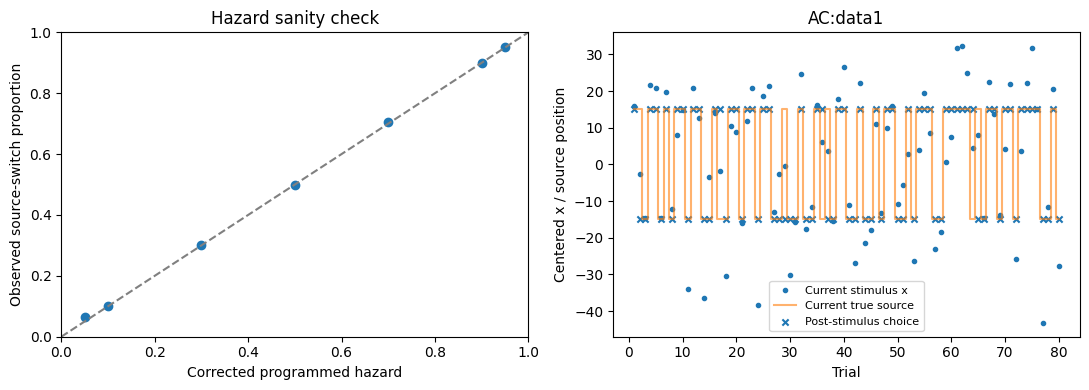

In [4]:
# Compare realized source switches with programmed hazards; exclude each session's first slot.
# Use all generated experimental slots, including unanswered ones, for this generator check.
generated = trials_df.loc[~trials_df.is_practice & trials_df.source_switch.notna()].copy()
generated["hazard_rounded"] = generated.hazard_rate.round(8)
hazard_check = generated.groupby("hazard_rounded").agg(
    transitions=("source_switch", "size"), observed_switch_rate=("source_switch", "mean"))
display(hazard_check)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot([0, 1], [0, 1], "--", color="gray")
axes[0].scatter(hazard_check.index, hazard_check.observed_switch_rate.astype(float))
axes[0].set(xlabel="Corrected programmed hazard", ylabel="Observed source-switch proportion",
            title="Hazard sanity check", xlim=(0, 1), ylim=(0, 1))
example_id = analysis_trials.session_uid.iloc[0]
example = analysis_trials.loc[analysis_trials.session_uid.eq(example_id)].head(80)
axes[1].plot(example.trial, example.stimulus_x_centered, ".", label="Current stimulus x")
source_x = np.where(example.true_source.eq(1), example.source_left_x, example.source_right_x)
choice_x = np.where(example.choice.eq(1), example.source_left_x, example.source_right_x)
center = (example.source_left_x + example.source_right_x) / 2
axes[1].step(example.trial, source_x-center, where="mid", alpha=.6, label="Current true source")
axes[1].scatter(example.trial, choice_x-center, marker="x", s=20, label="Post-stimulus choice")
axes[1].set(xlabel="Trial", ylabel="Centered x / source position", title=example_id)
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()


The hazard plot is a stochastic plausibility check, not a test that observed frequencies must equal their expectations exactly. The trace illustrates the documented pairing; the GUI code establishes timing. Differences between stimulus side and source/choice are expected under noisy sampling.

The two requested dataframes and the filtered `analysis_trials` are now available in memory. Raw MATLAB arrays/dictionaries in metadata are retained for auditability. Optional CSV exports below stringify those nested fields; keep the in-memory tables for structured access.

In [5]:
metadata_df

,session_uid,subject_id,session_number,is_practice,source_file,matlab_variable,sex_recorded,n_stored_trials,n_responses,n_counter_raw,...,penalty_raw,sessionstart_matlab_datenum,session_ind_file_raw,planned_parameters_raw,cp_matches_source_switch,r_matches_source_run,source_left_x,source_left_y,source_right_x,source_right_y
0,AC:data1,AC,1,False,data/Glaze_Triangles/data_2AFC/raw_data/data_A...,data1,f,2000,2000,2000,...,NaN,NaN,7,"{'tau': [[1.4285714285714286, 10.0, 1.11111111...",True,True,34.5,27.0,64.5,27.0
1,AC:data2,AC,2,False,data/Glaze_Triangles/data_2AFC/raw_data/data_A...,data2,f,2000,2000,2000,...,NaN,NaN,7,"{'tau': [[10.0, 1.1111111111111112, 2.0, 3.333...",True,True,34.5,27.0,64.5,27.0
2,AC:data3,AC,3,False,data/Glaze_Triangles/data_2AFC/raw_data/data_A...,data3,f,2000,2000,2000,...,NaN,NaN,7,"{'tau': [[10, 20], [10, 20]], 'signaled': 2, '...",True,True,34.5,27.0,64.5,27.0
3,AC:data4,AC,4,False,data/Glaze_Triangles/data_2AFC/raw_data/data_A...,data4,f,2000,2000,2000,...,NaN,NaN,7,"{'tau': [[10.0, 1.1111111111111112], [10.0, 1....",True,True,34.5,27.0,64.5,27.0
4,AC:data5_practice,AC,5,True,data/Glaze_Triangles/data_2AFC/raw_data/data_A...,data5_practice,f,120,120,120,...,20.0,735431.584927,7,"{'tau': [], 'signaled': 0, 'sigma': 10, 'Hset'...",True,True,34.5,28.5,64.5,28.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
379,YZ1:data1,YZ1,1,False,data/Glaze_Triangles/data_2AFC/raw_data/data_Y...,data1,m,2000,2000,2000,...,NaN,735423.534322,4,"{'sigma': 12.24744871391589, 'signaled': 1, 'H...",True,True,34.5,28.5,64.5,28.5
380,YZ1:data2_practice,YZ1,2,True,data/Glaze_Triangles/data_2AFC/raw_data/data_Y...,data2_practice,m,120,120,120,...,NaN,735424.523167,4,"{'sigma': 10, 'signaled': 1, 'Hset': [[0.05, 0...",True,True,34.5,28.5,64.5,28.5
381,YZ1:data2,YZ1,2,False,data/Glaze_Triangles/data_2AFC/raw_data/data_Y...,data2,m,2000,2000,2000,...,NaN,735424.526137,4,"{'sigma': 10, 'signaled': 1, 'Hset': [[0.05, 0...",True,True,34.5,28.5,64.5,28.5
382,YZ1:data3_practice,YZ1,3,True,data/Glaze_Triangles/data_2AFC/raw_data/data_Y...,data3_practice,m,120,120,120,...,20.0,735426.526454,4,"{'sigma': 10, 'signaled': 0, 'Hset': [[0.3, 0....",True,True,34.5,28.5,64.5,28.5


<Axes: >

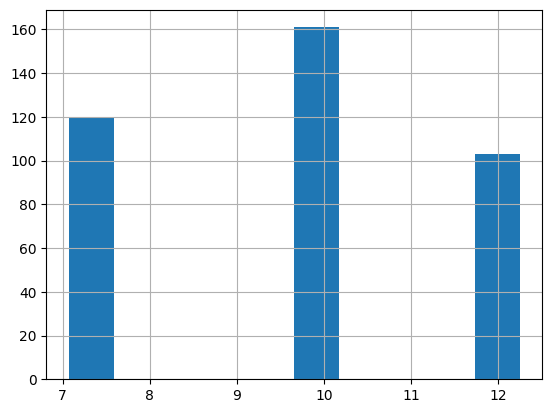

In [32]:
metadata_df['sigma'].hist()

<Axes: >

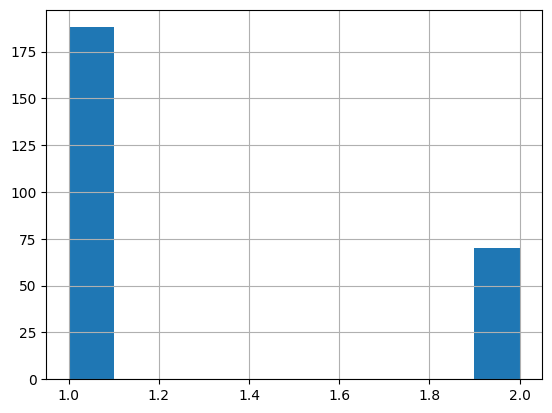

In [37]:
metadata_df['reward_raw'].hist()

In [39]:
metadata_df['feedback_condition'].value_counts()

feedback_condition
unsignaled    151
mixed         118
signaled      115
Name: count, dtype: int64

In [42]:
metadata_df.columns

Index(['session_uid', 'subject_id', 'session_number', 'is_practice',
       'source_file', 'matlab_variable', 'sex_recorded', 'n_stored_trials',
       'n_responses', 'n_counter_raw', 'feedback_condition',
       'planned_signaled_code', 'sigma', 'stimulus_variance',
       'n_hazard_blocks', 'hazard_block_lengths', 'Hset_raw', 'Hset_corrected',
       'tau_raw', 'hazard_reciprocal_corrected', 'Hset_reciprocal_corrected',
       'Hset_schedule_matches', 'reward_raw', 'penalty_raw',
       'sessionstart_matlab_datenum', 'session_ind_file_raw',
       'planned_parameters_raw', 'cp_matches_source_switch',
       'r_matches_source_run', 'source_left_x', 'source_left_y',
       'source_right_x', 'source_right_y'],
      dtype='object')

In [47]:
trials_df

,session_uid,subject_id,session_number,is_practice,trial,stimulus_x,stimulus_y,stimulus_x_centered,choice_raw,choice,...,r_raw,reward_raw,penalty_raw,hazard_rate,previous_true_source,previous_feedback_available,source_left_x,source_left_y,source_right_x,source_right_y
0,AC:data1,AC,1,False,1,65.375798,26.210271,15.875798,2,2,...,1,NaN,NaN,0.7,<NA>,<NA>,34.5,27.0,64.5,27.0
1,AC:data1,AC,1,False,2,46.797981,19.848892,-2.702019,1,1,...,2,NaN,NaN,0.7,2,True,34.5,27.0,64.5,27.0
2,AC:data1,AC,1,False,3,34.812274,34.448290,-14.687726,1,1,...,1,NaN,NaN,0.7,2,True,34.5,27.0,64.5,27.0
3,AC:data1,AC,1,False,4,71.070636,19.005090,21.570636,2,2,...,1,NaN,NaN,0.7,1,True,34.5,27.0,64.5,27.0
4,AC:data1,AC,1,False,5,70.249574,29.989261,20.749574,2,2,...,2,NaN,NaN,0.7,2,True,34.5,27.0,64.5,27.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
461555,YZ1:data3,YZ1,3,False,1996,76.939834,29.695089,27.439834,2,2,...,3,2.0,20.0,0.5,2,False,34.5,28.5,64.5,28.5
461556,YZ1:data3,YZ1,3,False,1997,55.166564,27.462611,5.666564,2,2,...,4,2.0,20.0,0.5,2,False,34.5,28.5,64.5,28.5
461557,YZ1:data3,YZ1,3,False,1998,53.774706,30.463574,4.274706,2,2,...,5,2.0,20.0,0.5,2,False,34.5,28.5,64.5,28.5
461558,YZ1:data3,YZ1,3,False,1999,24.964102,31.968694,-24.535898,1,1,...,1,2.0,20.0,0.5,2,False,34.5,28.5,64.5,28.5


In [62]:
trials_df[['hazard_left_raw','hazard_right_raw','hazard_left','hazard_right','hazard_reciprocal_corrected']]

,hazard_left_raw,hazard_right_raw,hazard_left,hazard_right,hazard_reciprocal_corrected
0,0.7,0.7,0.7,0.7,False
1,0.7,0.7,0.7,0.7,False
2,0.7,0.7,0.7,0.7,False
3,0.7,0.7,0.7,0.7,False
4,0.7,0.7,0.7,0.7,False
...,...,...,...,...,...
461555,0.5,0.5,0.5,0.5,False
461556,0.5,0.5,0.5,0.5,False
461557,0.5,0.5,0.5,0.5,False
461558,0.5,0.5,0.5,0.5,False


<Axes: >

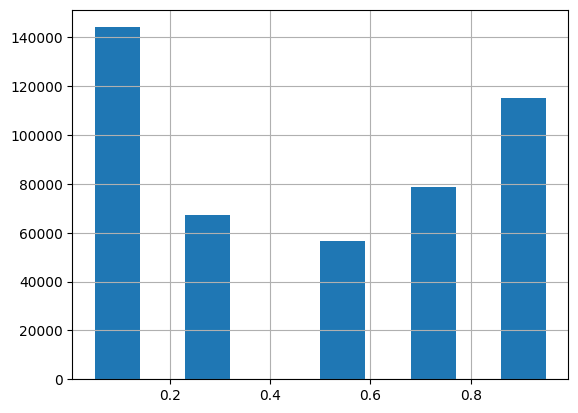

In [63]:
trials_df['hazard_left'].hist()

In [64]:
np.all(trials_df['hazard_left'].to_numpy() == trials_df['hazard_right'].to_numpy())

True

In [48]:
trials_df.columns

Index(['session_uid', 'subject_id', 'session_number', 'is_practice', 'trial',
       'stimulus_x', 'stimulus_y', 'stimulus_x_centered', 'choice_raw',
       'choice', 'response_recorded', 'true_source', 'correct', 'rt_ms',
       'feedback_after_choice', 'feedback_condition', 'sigma',
       'stimulus_variance', 'hazard_left_raw', 'hazard_right_raw',
       'hazard_left', 'hazard_right', 'hazard_reciprocal_corrected',
       'hazard_block', 'trial_in_hazard_block', 'source_switch',
       'source_run_length', 'cp_raw', 'r_raw', 'reward_raw', 'penalty_raw',
       'hazard_rate', 'previous_true_source', 'previous_feedback_available',
       'source_left_x', 'source_left_y', 'source_right_x', 'source_right_y'],
      dtype='object')

In [67]:
EXPORT_CSV = True
if EXPORT_CSV:
    output = ROOT / "Glaze_Triangles" / "processed"
    output.mkdir(exist_ok=True)
    metadata_df.to_csv(output / "session_metadata.csv", index=False)
    trials_df.to_csv(output / "trials.csv", index=False)
    print(f"Saved metadata and all stored trial slots to {output}")


Saved metadata and all stored trial slots to /workspaces/behavioral_data_reanalyses_IB/Glaze_Triangles/processed


In [80]:
sigma_vals = trials_df['sigma'].unique()
mean_left_ = metadata_df['source_left_x'].iat[0]
mean_right_ = metadata_df['source_right_x'].iat[0]
mean_left = mean_left_ - (mean_left_ + mean_right_)/2
mean_right = mean_right_ - (mean_left_ + mean_right_)/2

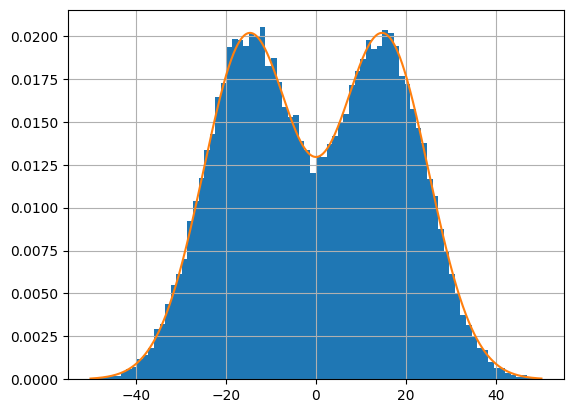

In [ ]:
from scipy.stats import norm

sigma = sigma_vals[0]
x = np.arange(-50,50+0.1,0.1)
P_sample_g_left = norm.pdf(x, loc=mean_left, scale=sigma)
P_sample_g_right = norm.pdf(x, loc=mean_right, scale=sigma)
P_sample = (P_sample_g_left + P_sample_g_right) / 2

df_ = trials_df.loc[trials_df['sigma']==sigma]
df_['stimulus_x_centered'].hist(bins=80, density=True)
plt.plot(x, P_sample)

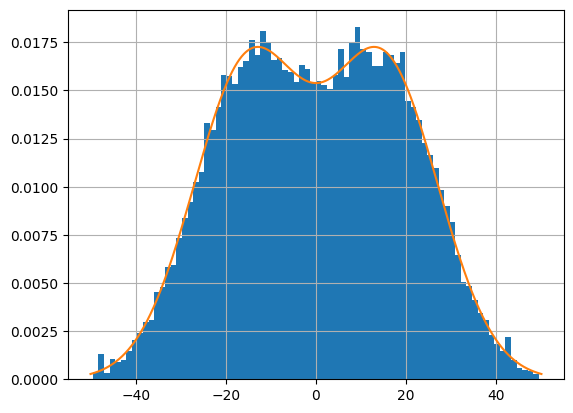

In [87]:
sigma = sigma_vals[1]
x = np.arange(-50,50+0.1,0.1)
P_sample_g_left = norm.pdf(x, loc=mean_left, scale=sigma)
P_sample_g_right = norm.pdf(x, loc=mean_right, scale=sigma)
P_sample = (P_sample_g_left + P_sample_g_right) / 2

df_ = trials_df.loc[trials_df['sigma']==sigma]
df_['stimulus_x_centered'].hist(bins=80, density=True)
plt.plot(x, P_sample)

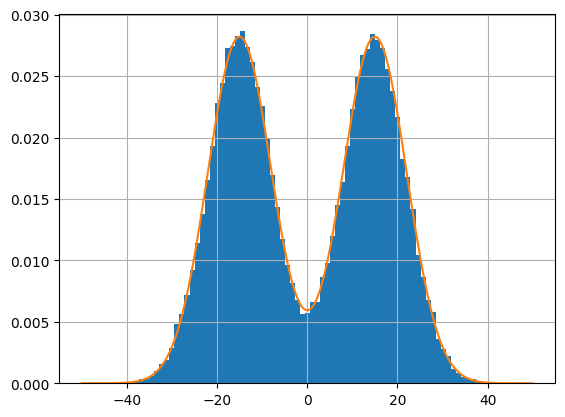

In [88]:
sigma = sigma_vals[2]
x = np.arange(-50,50+0.1,0.1)
P_sample_g_left = norm.pdf(x, loc=mean_left, scale=sigma)
P_sample_g_right = norm.pdf(x, loc=mean_right, scale=sigma)
P_sample = (P_sample_g_left + P_sample_g_right) / 2

df_ = trials_df.loc[trials_df['sigma']==sigma]
df_['stimulus_x_centered'].hist(bins=80, density=True)
plt.plot(x, P_sample)